# Baseline Model: SARIMA

Classical seasonal ARIMA baseline on **total citywide daily volume**
(not yet category-level — that comes in `03_prophet_model.ipynb` and
`04_lightgbm_model.ipynb`). Purpose: establish a defensible, simple
benchmark before reaching for more complex models. If a sophisticated
model can't beat this, it isn't earning its complexity.

**Why SARIMA first**: demonstrates time-series fundamentals (stationarity,
ACF/PACF, seasonal differencing) rather than skipping straight to ML.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')

WAREHOUSE_PATH = Path.cwd().parents[1] / "pipeline" / "warehouse" / "nyc311.duckdb"
con = duckdb.connect(str(WAREHOUSE_PATH), read_only=True)

df = con.execute("""
    SELECT request_date, SUM(request_count) as total_requests
    FROM fct_daily_demand
    GROUP BY request_date
    ORDER BY request_date
""").fetchdf()

# Apply the same trailing-partial-day trim from EDA
cutoff_date = df['request_date'].max()
df = df[df['request_date'] < cutoff_date].copy()

df = df.set_index('request_date')
df.index = pd.DatetimeIndex(df.index).to_period('D').to_timestamp()  # ensure clean daily freq

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Shape: (1113, 1)
Date range: 2023-06-01 00:00:00 to 2026-06-17 00:00:00


,total_requests
request_date,
2023-06-01,4456.0
2023-06-02,4839.0
2023-06-03,4027.0
2023-06-04,4428.0
2023-06-05,4350.0


## Train/test split

**Critical**: time series data must never be randomly shuffled into
train/test. Splitting chronologically — train on the past, test on a
held-out future window — is the only valid way to simulate real
forecasting conditions. Using the last 90 days as a test set (roughly
one quarter), leaving ~3 years for training.

Train: 2023-06-01 to 2026-03-19 (1023 days)
Test:  2026-03-20 to 2026-06-17 (90 days)


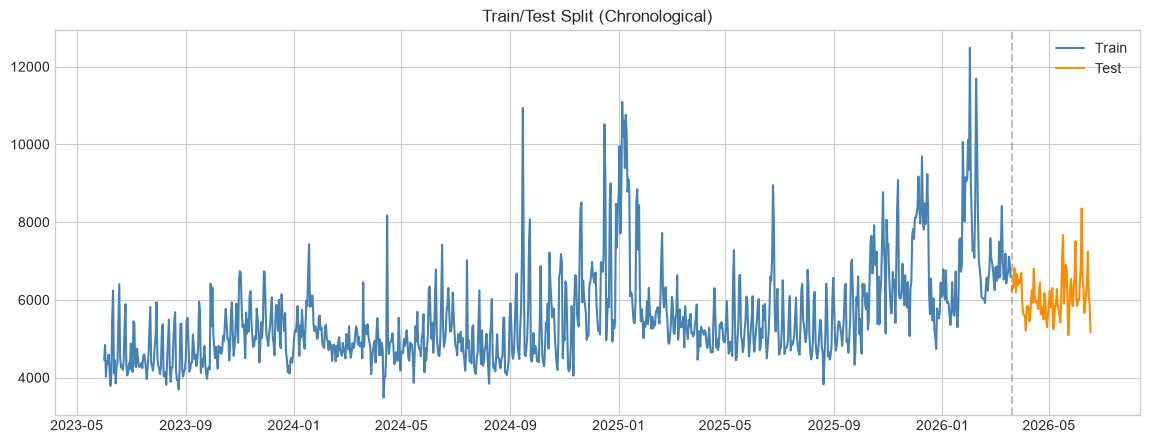

In [2]:
TEST_DAYS = 90

train = df.iloc[:-TEST_DAYS]
test = df.iloc[-TEST_DAYS:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train['total_requests'], label='Train', color='steelblue')
ax.plot(test.index, test['total_requests'], label='Test', color='darkorange')
ax.axvline(test.index.min(), color='gray', linestyle='--', alpha=0.5)
ax.set_title('Train/Test Split (Chronological)')
ax.legend()
plt.show()

## Stationarity check

SARIMA requires understanding whether the series is stationary (constant
mean/variance over time) before choosing differencing order. Using the
Augmented Dickey-Fuller test — formally testing this rather than
guessing from the chart, even though the upward trend found in EDA
already suggests non-stationarity.

In [3]:
def run_adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"--- {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Stationary at 5%? {'Yes' if result[1] < 0.05 else 'No'}")
    print()

run_adf_test(train['total_requests'], "Original series")

train_diff = train['total_requests'].diff().dropna()
run_adf_test(train_diff, "After 1st differencing")

train_diff7 = train['total_requests'].diff(7).dropna()
run_adf_test(train_diff7, "After seasonal differencing (lag=7)")

--- Original series ---
ADF Statistic: -3.2831
p-value: 0.0156
Stationary at 5%? Yes

--- After 1st differencing ---
ADF Statistic: -10.2651
p-value: 0.0000
Stationary at 5%? Yes

--- After seasonal differencing (lag=7) ---
ADF Statistic: -8.2647
p-value: 0.0000
Stationary at 5%? Yes



**Observations:**

- **Original series tests as stationary** (p=0.0156) — slightly
  surprising given the clear upward trend found in EDA. Likely
  explained by strong short-term mean reversion (weekly seasonality)
  dominating the ADF test's sensitivity, even with slow multi-year
  drift present. The trend is real (confirmed visually and via
  year-over-year category growth in EDA) but not strong/abrupt
  enough for ADF to flag at this sample size.
- **Both differenced versions also stationary**, as expected
  (differencing should not break stationarity once already present).
- **Practical choice**: given the modest trend and dominant weekly
  seasonality, will proceed with `d=0` (no regular differencing) but
  `D=1` (seasonal differencing at lag 7), letting SARIMA's seasonal
  AR/MA terms handle the weekly pattern directly. Will compare
  against a `d=1` alternative if residual diagnostics suggest
  leftover trend.

## ACF/PACF — choosing AR and MA orders

Using autocorrelation (ACF) and partial autocorrelation (PACF) plots on
the seasonally-differenced series to select reasonable starting p, q
(non-seasonal) and P, Q (seasonal) orders before fitting.

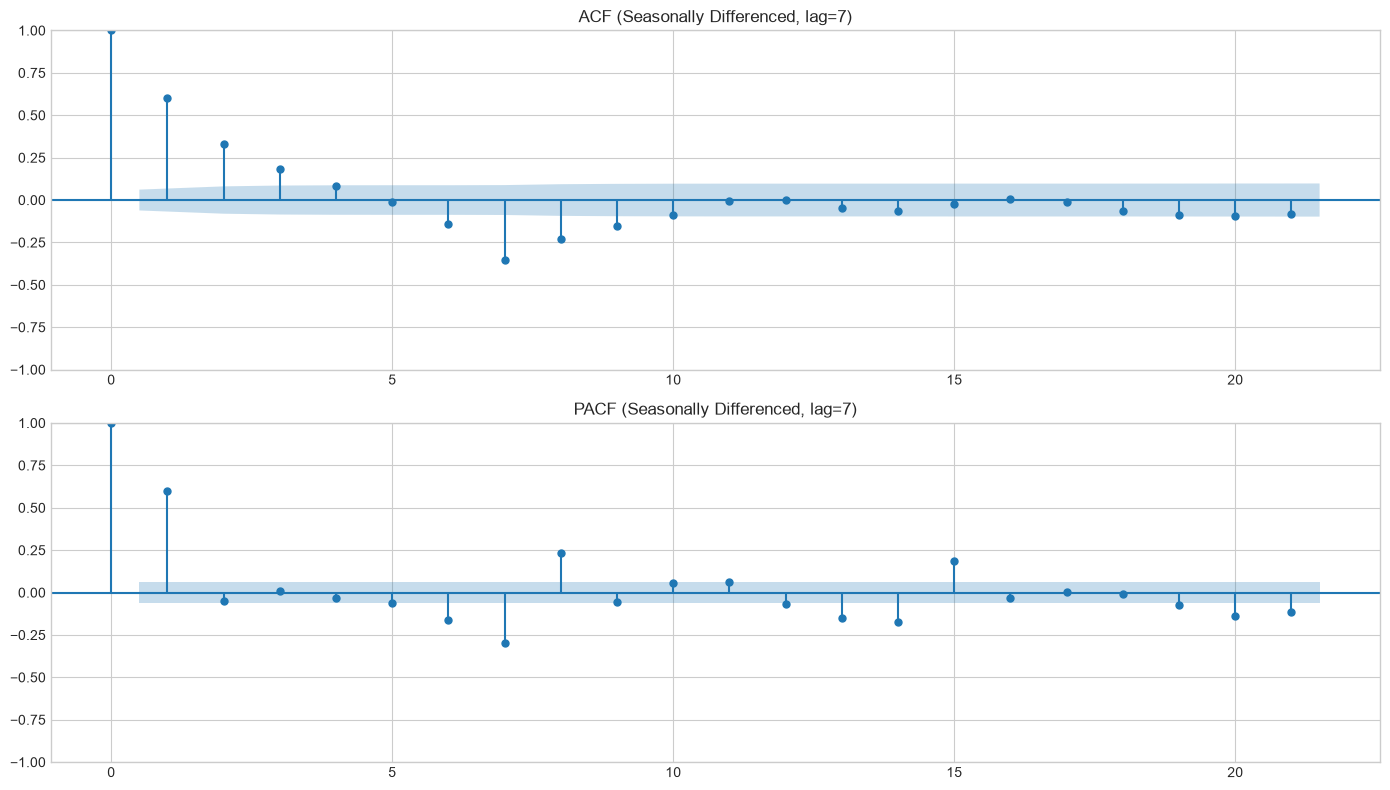

In [4]:
seasonal_diff = train['total_requests'].diff(7).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(seasonal_diff, lags=21, ax=axes[0])
axes[0].set_title('ACF (Seasonally Differenced, lag=7)')
plot_pacf(seasonal_diff, lags=21, ax=axes[1])
axes[1].set_title('PACF (Seasonally Differenced, lag=7)')
plt.tight_layout()
plt.show()

**Observations:**

- **ACF decays gradually (lags 1-4)**, **PACF cuts off sharply after
  lag 1** — classic AR(1) signature for the non-seasonal component.
  Suggests starting point: `p=1, d=0, q=0`.
- **Strong negative spike at lag 7** in both plots (ACF: -0.38, PACF:
  -0.30), with a smaller echo near lag 14 — confirms weekly
  seasonality requires an explicit seasonal term. Negative spike
  post-differencing suggests seasonal MA: `Q=1`.
- **Starting SARIMA order**: `(p,d,q)(P,D,Q,7)` = `(1,0,0)(0,1,1,7)`.
  Will fit this as a baseline, then compare against 1-2 nearby
  configurations to confirm it's not clearly suboptimal — not doing
  full grid search, since the brief scopes this as a baseline, not
  the primary model.

## Fit SARIMA model

Fitting `SARIMA(1,0,0)(0,1,1,7)` per the ACF/PACF analysis above, on
the training set only, then forecasting the 90-day test window.

In [5]:
order = (1, 0, 0)
seasonal_order = (0, 1, 1, 7)

model = SARIMAX(
    train['total_requests'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = model.fit(disp=False)
print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                      total_requests   No. Observations:                 1023
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood               -8069.456
Date:                             Sun, 21 Jun 2026   AIC                          16144.911
Time:                                     21:12:24   BIC                          16159.658
Sample:                                 06-01-2023   HQIC                         16150.514
                                      - 03-19-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6970      0.014     49.193      0.000       0.669       0.725
ma.S.L7       -0.8567      

**Observations:**

- **Model converged cleanly**, both coefficients highly significant
  (AR(1)=0.697, seasonal MA=-0.857, p<0.001 for both).
- **Ljung-Box p=0.98** — residuals show no remaining autocorrelation,
  confirming the model captured the main temporal structure.
- **Jarque-Bera p<0.001, kurtosis=8.38** (vs. 3.0 for normal) —
  residuals are heavy-tailed and right-skewed. Consistent with EDA
  findings: spike events (e.g. HEAT/HOT WATER cold snaps) aren't well
  captured by a single linear AR/seasonal-MA structure. This is an
  honest limitation, not a fitting error — flagged for comparison
  against Prophet/LightGBM, which may handle these events better via
  explicit regressors or tree splits.

MAE:  933.8
RMSE: 1028.4
MAPE: 15.87%


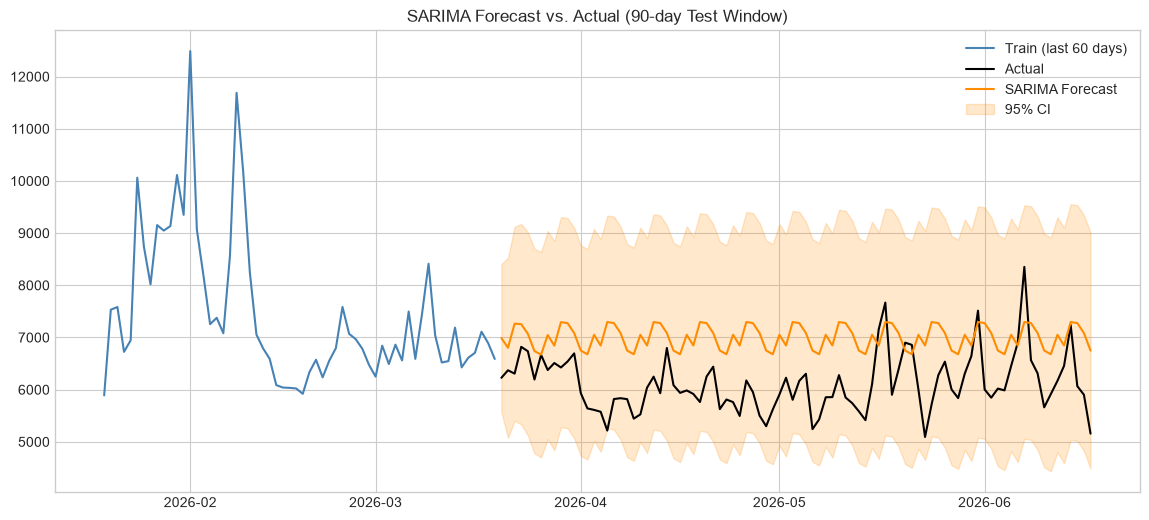

In [6]:
forecast_result = sarima_fit.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

mae = mean_absolute_error(test['total_requests'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test['total_requests'], forecast_mean))
mape = mean_absolute_percentage_error(test['total_requests'], forecast_mean) * 100

print(f"MAE:  {mae:.1f}")
print(f"RMSE: {rmse:.1f}")
print(f"MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-60:], train['total_requests'].iloc[-60:], label='Train (last 60 days)', color='steelblue')
ax.plot(test.index, test['total_requests'], label='Actual', color='black')
ax.plot(test.index, forecast_mean, label='SARIMA Forecast', color='darkorange')
ax.fill_between(test.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='darkorange', alpha=0.2, label='95% CI')
ax.legend()
ax.set_title('SARIMA Forecast vs. Actual (90-day Test Window)')
plt.show()

**Observations:**

- **MAE: 933.8 | RMSE: 1028.4 | MAPE: 15.87%** — this is the baseline
  every subsequent model must beat.
- **Forecast captures weekly shape correctly but is systematically
  biased high** for most of the test window (April–June), often by
  1,000+ requests/day.
- **Likely cause**: training ends in March, right after a winter
  HEAT/HOT WATER peak (per EDA, this category swings from ~6,000+ in
  winter to near-zero by spring). A 7-day seasonal term captures
  weekly patterns but **not** this yearly on/off cycle — the AR(1)
  term partially carries the elevated winter level forward into a
  season where it should be collapsing.
- **Implication**: this is a real structural limitation of
  citywide-aggregate SARIMA with weekly-only seasonality, not a
  fitting error. Strong evidence that (a) yearly seasonal terms or
  (b) category-level modeling (where HEAT/HOT WATER's collapse is
  modeled explicitly rather than absorbed into a single noisy
  aggregate) should outperform this baseline. Will check both in
  the model comparison.

## Summary

**Baseline established**: SARIMA(1,0,0)(0,1,1,7) on citywide daily
volume — MAE 933.8, RMSE 1028.4, MAPE 15.87%.

**Key limitation identified**: a single 7-day seasonal term captures
weekly patterns but not the yearly HEAT/HOT WATER on/off cycle found
in EDA. A true yearly SARIMA term (s=365) is impractical here,
computationally expensive and numerically unstable at that seasonal
period on daily data. This is precisely why Prophet (native support
for multiple simultaneous seasonalities via Fourier terms) is the
next model tested, rather than attempting to force SARIMA to handle
both cycles at once.

**Carrying forward**: this MAPE (15.87%) is the bar Prophet and
LightGBM need to clear. Given the identified bias mechanism, expect
the largest gains to come from models that either (a) explicitly
model yearly seasonality, or (b) forecast HEAT/HOT WATER separately
from the noisier aggregate.